# Model Training
In this notebook, we will train a simple linear regression model

## a. Imports

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

## b. Loading the data

In [28]:
df = pd.read_csv("../data/processed/auto-mpg-clean.csv")
print("Successfully loaded the data")

Successfully loaded the data


## c. Initializing the target and features

In [29]:
X = df["horsepower"].values
Y = df["mpg"].values

## d. Computing the slope 'm' and intercept 'b'

### Simple Linear Regression Formula

The regression line is:

$$
y = m x + b
$$

where

$$
m = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}
\qquad
b = \bar{y} - m\,\bar{x}
$$

- $m$ = slope (coefficient)  
- $b$ = intercept

#### d.1 Calculating the mean

In [30]:
x_mean = np.mean(X)
y_mean = np.mean(Y)

print("x_mean:", x_mean)
print("y_mean:", y_mean)

x_mean: 104.46938775510205
y_mean: 23.445918367346938


#### d.2 Calculating the slope 'm'

In [31]:
numerator = np.sum((X - x_mean) * (Y - y_mean))
denominator = np.sum((X - x_mean) ** 2)

m = numerator / denominator

print(f"Slope m = {m:.6f}")

Slope m = -0.157845


#### d.3 Calculating the intercept 'b'

In [32]:
b = y_mean - m * x_mean

print(f"Intercept b = {b:.6f}")

Intercept b = 39.935861


## e. Making predictions

**Regression Line (Y_pred) :**

$$
\hat{y} = mx + b
$$

In [33]:
Y_pred = m * X +b

## f. Model Evaluation


### f.1 Coefficient of Determination (R²)

**1. Residual Sum of Squares (SS_res):**
$$
SS_{res} = \sum (y_i - \hat{y}_i)^2
$$

In [34]:
SS_res = np.sum((Y - Y_pred) ** 2)

**2. Total Sum of Squares (SS_tot):**
$$
SS_{tot} = \sum (y_i - \bar{y})^2
$$

In [35]:
SS_tot = np.sum((Y - y_mean) ** 2)

**3. R² Calculation:**
$$
R^2 = 1- \frac{SS_{res}}{SS_{tot}}
$$

In [36]:
r2 = 1 - (SS_res / SS_tot)
print(f"R² = {r2:.6f}")

R² = 0.605948


### f.2 Mean Squared Error (MSE)

$$
MSE = \frac{1}{n} \sum (y_i - \hat{y}_i)^2
$$

In [37]:
mse = np.mean((Y - Y_pred) ** 2)
print(f"MSE = {mse:.4f}")

MSE = 23.9437


### f.3 Mean Absolute Error (MAE)

$$
MAE = \frac{1}{n} \sum |y_i - \hat{y}_i|
$$

In [38]:
mae = np.mean( np.abs( Y - Y_pred))
print(f"MAE = {mae:.4f}")

MAE = 3.8276


## f. Visualizing the regression line

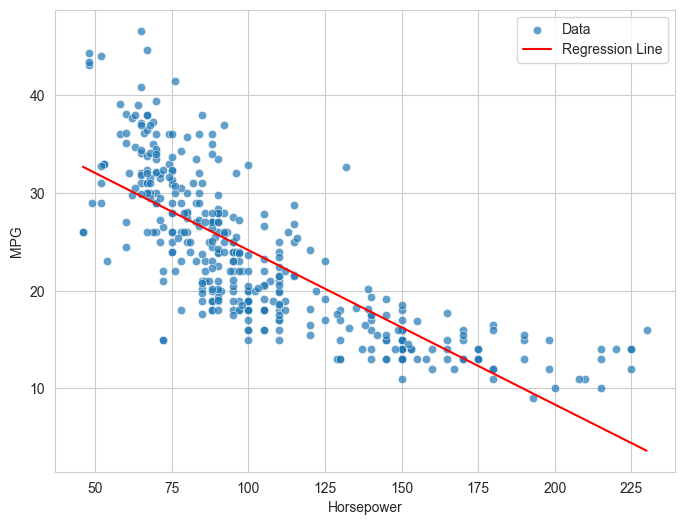

In [39]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=X, y=Y, alpha=0.7, label="Data")
xs = np.linspace(X.min(), X.max(), 200)
ys = m * xs + b
sns.lineplot(x=xs, y=ys, color="red", label="Regression Line")

plt.xlabel("Horsepower")
plt.ylabel("MPG")

plt.show()

## g. Residual plot

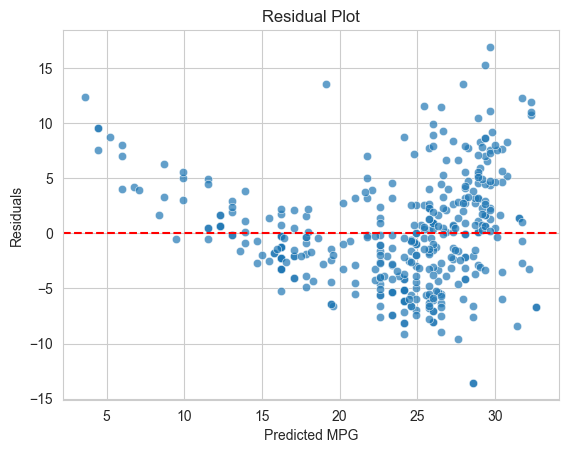

In [42]:
residuals = Y - Y_pred
sns.scatterplot(x=Y_pred, y=residuals, alpha=0.7)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")

plt.title("Residual Plot")
plt.show()

## h. Verifying slope and intercept with sklearn

In [40]:
from sklearn.linear_model import LinearRegression

X_reshaped = X.reshape(-1, 1)
model = LinearRegression()
model.fit(X_reshaped, Y)

print("Sklearn slope:", model.coef_[0])
print("Sklearn intercept:", model.intercept_)
print("Manual slope:", m)
print("Manual intercept:", b)

Sklearn slope: -0.1578447333536537
Sklearn intercept: 39.935861021170474
Manual slope: -0.15784473335365362
Manual intercept: 39.93586102117047


## i. Verifying metrics with sklearn

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

r2_sklearn = r2_score(Y, model.predict(X_reshaped))
mse_sklearn = mean_squared_error(Y, model.predict(X_reshaped))
mae_sklearn = mean_absolute_error(Y, model.predict(X_reshaped))

print("Sklearn R²:", r2_sklearn)
print("Manual R²:", r2)

print("Sklearn MSE:", mse_sklearn)
print("Manual MSE:", mse)

print("Sklearn MAE:", mae_sklearn)
print("Manual MAE:", mae)

Sklearn R²: 0.6059482578894348
Manual R²: 0.6059482578894348
Sklearn MSE: 23.943662938603108
Manual MSE: 23.943662938603108
Sklearn MAE: 3.8275871459582205
Manual MAE: 3.8275871459582214
